In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

# Wczytanie danych
movies = pd.read_csv('./ml-100k/ml-latest-small/movies.csv')
ratings = pd.read_csv('./ml-100k/ml-latest-small/ratings.csv')

print(f"W zbiorze znajduje się {len(movies)} filmów oraz {len(ratings)} ocen użytkowników.")
print("\nPierwsze wiersze tabeli filmów:")
display(movies.head())

W zbiorze znajduje się 9742 filmów oraz 100836 ocen użytkowników.

Pierwsze wiersze tabeli filmów:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Obliczenie macierzy podobieństwa

Jedynie na podstawie gatunków, które w zbiorze są wypisane z separatorem "|".

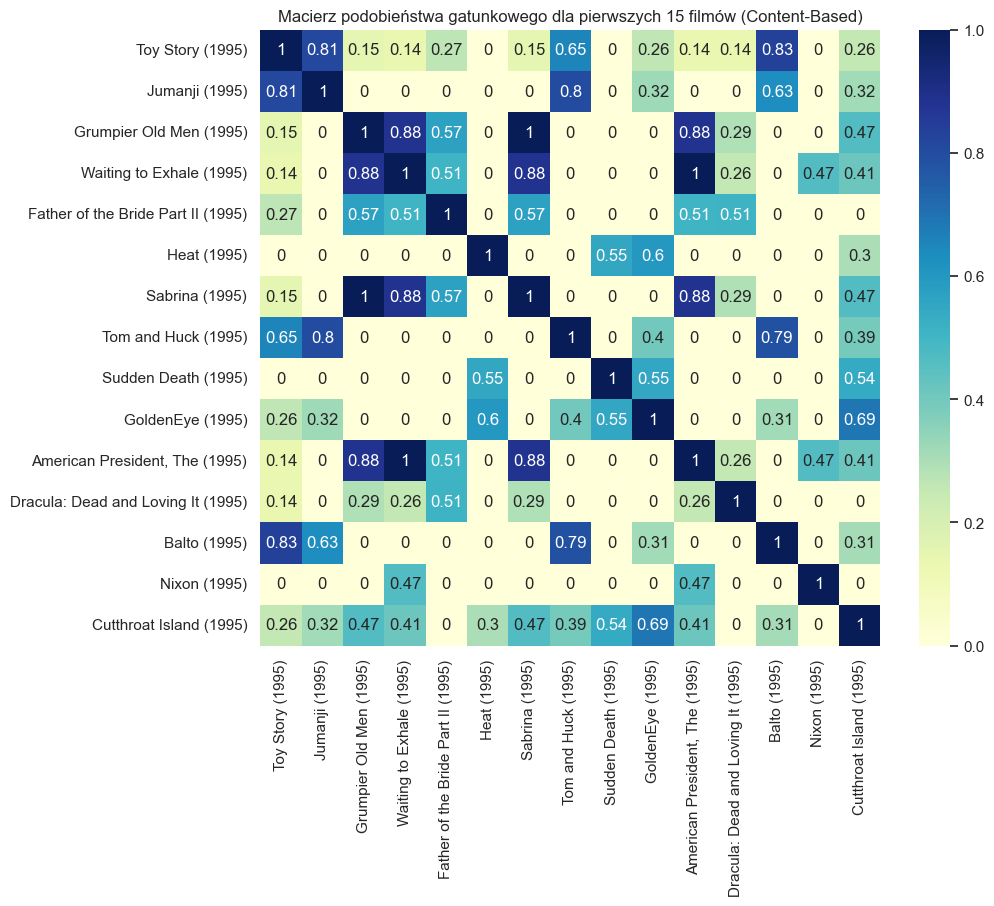

In [2]:
tfidf = TfidfVectorizer(token_pattern=r'[a-zA-Z0-9\-]+')
tfidf_matrix = tfidf.fit_transform(movies['genres'].fillna(''))

# Obliczamy podobieństwo cosinusowe "każdy z każdym"
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim[:15, :15], annot=True, cmap="YlGnBu", 
            xticklabels=movies['title'].iloc[:15], 
            yticklabels=movies['title'].iloc[:15])
plt.xticks(rotation=90)
plt.title("Macierz podobieństwa gatunkowego dla pierwszych 15 filmów (Content-Based)")
plt.show()

## Funkcja polecająca filmy na podstawie podobieństwa gatunków


Korzystamy ze stworzonej przed chwilą macierzy podobieństwa cosinuowego

In [3]:
def get_content_recommendation_with_xai(target_title, top_n=3):
    # Znajdź indeks filmu o podanym tytule
    try:
        idx = movies[movies['title'].str.contains(target_title, case=False)].index[0]
    except IndexError:
        return f"Nie znaleziono filmu '{target_title}' w bazie."
        
    # Pobierz wektor podobieństwa dla tego filmu
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Posortuj filmy po wyniku podobieństwa (od najwyższego)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Pomiń pierwszy element (bo to ten sam film, podobieństwo do samego siebie = 1.0)
    top_movies = sim_scores[1:top_n+1]
    
    print(f"Ponieważ polubiłeś film: {movies['title'].iloc[idx]} ({movies['genres'].iloc[idx]})\n")
    print("Rekomendujemy Ci następujące tytuły:")
    
    for i, score in top_movies:
        recommended_title = movies['title'].iloc[i]
        recommended_genres = movies['genres'].iloc[i]
        
        # Proste, matematyczne wyjaśnienie cech (XAI)
        print(f"{recommended_title}")
        print(f"   - Gatunki: {recommended_genres}")
        print(f"   - Współczynnik dopasowania (Score): {score:.2f}")
        print(f"   - WYJAŚNIENIE: Ten film dzieli dokładnie te same cechy gatunkowe w stopniu {score*100:.0f}%.")
        print("-" * 50)

# test: Wpisz tutaj fragment tytułu, np. "Toy Story" lub "Matrix"
get_content_recommendation_with_xai("Matrix")

Ponieważ polubiłeś film: Matrix, The (1999) (Action|Sci-Fi|Thriller)

Rekomendujemy Ci następujące tytuły:
Screamers (1995)
   - Gatunki: Action|Sci-Fi|Thriller
   - Współczynnik dopasowania (Score): 1.00
   - WYJAŚNIENIE: Ten film dzieli dokładnie te same cechy gatunkowe w stopniu 100%.
--------------------------------------------------
Johnny Mnemonic (1995)
   - Gatunki: Action|Sci-Fi|Thriller
   - Współczynnik dopasowania (Score): 1.00
   - WYJAŚNIENIE: Ten film dzieli dokładnie te same cechy gatunkowe w stopniu 100%.
--------------------------------------------------
Virtuosity (1995)
   - Gatunki: Action|Sci-Fi|Thriller
   - Współczynnik dopasowania (Score): 1.00
   - WYJAŚNIENIE: Ten film dzieli dokładnie te same cechy gatunkowe w stopniu 100%.
--------------------------------------------------


## Item based collaborative filtering


Szukanie "Podobnych produktów" to znaczy analizujemy podobieństwo filmów w sensie dostawania podobnych ocen od tych samych osób.
Jeśli osoby wysoko oceniające Toy Story wysoko oceniały również Potwory i Spółka to filmy te będą mieć wyższe podobieństwo.


In [4]:
# Tworzymy tabelę przestawną: Wiersze = movieId, Kolumny = userId, Wartości = rating
user_item_matrix = ratings.pivot(index='movieId', columns='userId', values='rating').fillna(0)

user_item_matrix = user_item_matrix.reindex(movies['movieId'], fill_value=0)

cosine_sim_collaborative = cosine_similarity(user_item_matrix)

print(f"Macierz Content-Based kształt: {cosine_sim.shape}")
print(f"Macierz Collaborative Filtering kształt: {cosine_sim_collaborative.shape}")

Macierz Content-Based kształt: (9742, 9742)
Macierz Collaborative Filtering kształt: (9742, 9742)


## Funkcja łącząca collaborative i content-based filtering

Z parametrem alfa pozwalającym na manipulowanie siły uwzględniania jednego lub drugiego rodzaju filtracji.

In [5]:
def get_hybrid_recommendation_with_explained_xai(target_title, alpha=0.5, top_n=3):
    """
    alpha = 1.0 -> tylko Content-Based (Gatunki)
    alpha = 0.0 -> tylko Collaborative Filtering (Społeczność)
    alpha = 0.5 -> idealna hybryda (pół na pół)
    """
    # Znajdź indeks filmu bazowego
    try:
        idx = movies[movies['title'].str.contains(target_title, case=False)].index[0]
    except IndexError:
        return f"Nie znaleziono filmu '{target_title}' w bazie."
    
    base_movie_title = movies['title'].iloc[idx]
    base_movie_genres = movies['genres'].iloc[idx]
    
    # Pobieramy wektory podobieństwa z obu modeli dla tego jednego filmu
    cb_scores = cosine_sim[idx]
    cf_scores = cosine_sim_collaborative[idx]
    
    hybrid_scores = alpha * cb_scores + (1 - alpha) * cf_scores
    
    # Pakujemy wyniki w listę indeksów i sortujemy od najwyższego wyniku
    sim_scores = list(enumerate(hybrid_scores))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Pobieramy najlepsze wyniki (omijamy pierwszy element, bo to ten sam film)
    top_movies = sim_scores[1:top_n+1]
    
    print(f"Ponieważ polubiłeś film: {base_movie_title}")
    print(f"Ustawienia modelu: Waga Content-Based = {alpha*100:.0f}%, Waga Collaborative = {(1-alpha)*100:.0f}%\n")
    print("="*60)
    print(f"TOP {top_n} HYBRYDOWE REKOMENDACJE DLA CIEBIE:")
    print("="*60)
    
    for i, score in top_movies:
        rec_title = movies['title'].iloc[i]
        rec_genres = movies['genres'].iloc[i]
        
        # Pobieramy cząstkowe, surowe wyniki przed nałożeniem wag
        raw_cb = cb_scores[i]
        raw_cf = cf_scores[i]
        
        # Obliczamy ile realnie punktów do końcowego wyniku przyniosła każda ze składowych
        contrib_cb = alpha * raw_cb
        contrib_cf = (1 - alpha) * raw_cf
        
        # Przeliczamy to na procenty (udział sił w ostatecznej decyzji)
        total_contribution = contrib_cb + contrib_cf
        if total_contribution > 0:
            pct_cb = (contrib_cb / total_contribution) * 100
            pct_cf = (contrib_cf / total_contribution) * 100
        else:
            pct_cb, pct_cf = 0, 0
            
        print(f"{rec_title}")
        print(f"   - Gatunki: {rec_genres}")
        print(f"   - Całkowity Hybrid Score: {score:.3f}")
        print(f"   ANALIZA DECYZJI MODELU (XAI):")
        print(f"     - [{pct_cb:.1f}%] - Dopasowanie profilu fabularnego/gatunkowego")
        print(f"     - [{pct_cf:.1f}%] - Rekomendacja społeczności (inni ocenili podobnie)")
        
        # Generowanie dynamicznego, ludzkiego wyjaśnienia na podstawie dominującej siły
        if pct_cb > 60:
            print(f"   ↳ WYJAŚNIENIE: Ten film trafia do Ciebie głównie dlatego, że idealnie pokrywa się z klimatem '{base_movie_title}'.")
        elif pct_cf > 60:
            print(f"   ↳ WYJAŚNIENIE: Ten tytuł to hit społeczności. Ludzie, którzy uwielbiają '{base_movie_title}', masowo oglądają i świetnie oceniają ten film.")
        else:
            print(f"   ↳ WYJAŚNIENIE: Zrównoważony wybór. Film świetnie pasuje tematycznie, a dodatkowo jest bardzo wysoko ceniony przez osoby o zbliżonym guście.")

# test
get_hybrid_recommendation_with_explained_xai("Toy Story", alpha=0.45)

Ponieważ polubiłeś film: Toy Story (1995)
Ustawienia modelu: Waga Content-Based = 45%, Waga Collaborative = 55%

TOP 3 HYBRYDOWE REKOMENDACJE DLA CIEBIE:
Toy Story 2 (1999)
   - Gatunki: Adventure|Animation|Children|Comedy|Fantasy
   - Całkowity Hybrid Score: 0.765
   ANALIZA DECYZJI MODELU (XAI):
     - [58.8%] - Dopasowanie profilu fabularnego/gatunkowego
     - [41.2%] - Rekomendacja społeczności (inni ocenili podobnie)
   ↳ WYJAŚNIENIE: Zrównoważony wybór. Film świetnie pasuje tematycznie, a dodatkowo jest bardzo wysoko ceniony przez osoby o zbliżonym guście.
Monsters, Inc. (2001)
   - Gatunki: Adventure|Animation|Children|Comedy|Fantasy
   - Całkowity Hybrid Score: 0.728
   ANALIZA DECYZJI MODELU (XAI):
     - [61.9%] - Dopasowanie profilu fabularnego/gatunkowego
     - [38.1%] - Rekomendacja społeczności (inni ocenili podobnie)
   ↳ WYJAŚNIENIE: Ten film trafia do Ciebie głównie dlatego, że idealnie pokrywa się z klimatem 'Toy Story (1995)'.
Shrek (2001)
   - Gatunki: Adventure|A

# Ocena modelu

## Podział na zbiór treningowy i testowy

In [6]:
from sklearn.model_selection import train_test_split

train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"Liczba ocen w zbiorze treningowym: {len(train_ratings)}")
print(f"Liczba ocen w zbiorze testowym: {len(test_ratings)}")

# Tworzymy nową macierz użytkowników na podstawie TYLKO danych treningowych
user_item_matrix_train = train_ratings.pivot(index='movieId', columns='userId', values='rating').fillna(0)
user_item_matrix_train = user_item_matrix_train.reindex(movies['movieId'], fill_value=0)

cosine_sim_collaborative_train = cosine_similarity(user_item_matrix_train)

Liczba ocen w zbiorze treningowym: 80668
Liczba ocen w zbiorze testowym: 20168


Funkcja przewidująca ocenę filmu na podstawie macierzy podobieństwa

In [7]:
def predict_rating_hybrid(user_id, movie_id, alpha=0.5):
    """Przewiduje ocenę (od 0.5 do 5.0) dla danego użytkownika i filmu."""
    # Znajdujemy indeks wewnętrzny filmu
    try:
        movie_idx = movies[movies['movieId'] == movie_id].index[0]
    except IndexError:
        return 3.0 # Fallback, jeśli filmu nie ma w bazie
        
    # Pobieramy profil ocen tego użytkownika ze zbioru treningowego
    if user_id in user_item_matrix_train.columns:
        user_ratings = user_item_matrix_train[user_id].values
    else:
        return 3.0 # Użytkownik "widmo" (brak danych treningowych)
        
    # Indeksy filmów, które użytkownik faktycznie ocenił (ocena > 0)
    rated_indices = np.where(user_ratings > 0)[0]
    
    if len(rated_indices) == 0:
        return 3.0 # Brak historii użytkownika
        
    # Pobieramy wektory podobieństwa hybrydowego dla naszego filmu
    cb_sims = cosine_sim[movie_idx]
    cf_sims = cosine_sim_collaborative_train[movie_idx]
    hybrid_sims = alpha * cb_sims + (1 - alpha) * cf_sims
    
    # Wyciągamy podobieństwa tylko do filmów, które user ocenił
    weights = hybrid_sims[rated_indices]
    actual_ratings = user_ratings[rated_indices]
    
    # Obliczamy średnią ważoną: (podobieństwo * ocena) / suma_podobieństw
    sum_weights = np.sum(np.abs(weights))
    if sum_weights > 0:
        predicted_rating = np.sum(actual_ratings * weights) / sum_weights
    else:
        predicted_rating = 3.0 # Fallback, jeśli brak podobnych filmów
        
    # Ograniczamy wynik do widełek ocen w MovieLens (0.5 do 5.0)
    return float(np.clip(predicted_rating, 0.5, 5.0))

# test działania
print(f"Przykładowa prognoza oceny: {predict_rating_hybrid(user_id=1, movie_id=50, alpha=0.5):.2f} gwiazdki.")

Przykładowa prognoza oceny: 4.32 gwiazdki.


## Ewaluacja na zbiorze testowym 


Używamy alfa = 0.5 aby brać pod uwagę po równo collaborative i content-based filtering.

Miarą jest błąd śrdeniokwadratowy - sprawdzamy o ile gwiazdek średnio myli się model.

In [8]:
from sklearn.metrics import mean_squared_error
import math

# Pobieramy próbkę 1000 ocen ze zbioru testowego
sample_test = test_ratings.sample(n=1000, random_state=42)

true_ratings = []
predicted_ratings = []

for idx, row in sample_test.iterrows():
    u_id = int(row['userId'])
    m_id = int(row['movieId'])
    actual = float(row['rating'])
    
    # Przewidujemy naszą hybrydą (alpha = 0.5)
    pred = predict_rating_hybrid(u_id, m_id, alpha=0.5)
    
    true_ratings.append(actual)
    predicted_ratings.append(pred)

mse = mean_squared_error(true_ratings, predicted_ratings)
rmse = math.sqrt(mse)

print("\n" + "="*40)
print("RAPORT EWALUACJI MODELU HYBRYDOWEGO:")
print("="*40)
print(f" Rozmiar próbki testowej: {len(true_ratings)} ocen")
print(f" Błąd RMSE: {rmse:.4f}")
print(f" Błąd MAE (Średni błąd bezwzględny): {np.mean(np.abs(np.array(true_ratings) - np.array(predicted_ratings))):.4f}")
print("="*40)
print("Średnio model myli się o około +/- " + f"{rmse:.2f}" + " gwiazdki w ocenie filmu.")


RAPORT EWALUACJI MODELU HYBRYDOWEGO:
 Rozmiar próbki testowej: 1000 ocen
 Błąd RMSE: 0.9245
 Błąd MAE (Średni błąd bezwzględny): 0.7230
Średnio model myli się o około +/- 0.92 gwiazdki w ocenie filmu.
